In [1]:
# 📦 Librerías base
import pandas as pd
import numpy as np

# 📊 Visualización
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

# 🧰 Utilidades
import os
import time
from datetime import datetime



In [2]:
archivo="C:\\Users\\Admin\\Documents\\GitHub\\VJaroszewski-econ\\codigos\\Codigos_resNet\\Letras intrasf\\pasivos y activos_resumen.xlsx"
df=pd.read_excel(archivo)


In [3]:
# Limpiar nombres de columnas
df.columns = df.columns.str.strip()
df = df.rename(columns={
    "FECHA": "fecha",
    "RESERVAS INTERNACIONALES": "reservas",
    "Letras Intransferibles": "letras_intransferibles",
    "ADELANTOS  TRANSITORIOS  AL  GOBIERNO NACIONAL": "adelantos_gobierno",
    "TOTAL DEL ACTIVO ": "total_activo",
    "BASE MONETARIA ": "base_monetaria",
    "DEPOSITOS DEL GOBIERNO NACIONAL Y OTROS": "depositos_gobierno",
    "TITULOS EMITIDOS POR EL B.C.R.A. ": "titulos_bcra",
    "OTROS PASIVOS ": "otros_pasivos",
    "TOTAL DEL PASIVO ": "total_pasivo",
    "TOTAL DEL PATRIMONIO NETO ": "patrimonio_neto",
    "TC": "tc"
})

df["fecha"] = pd.to_datetime(df["fecha"])

In [4]:
# --- Crear df_usd: todas las columnas numéricas divididas por TC ---
cols_numericas = [c for c in df.columns if c not in ("fecha", "tc")]
df_usd = df[["fecha", "tc"]].copy()
for col in cols_numericas:
    df_usd[col] = df[col] / df["tc"]

In [5]:
df_usd

,fecha,tc,reservas,letras_intransferibles,adelantos_gobierno,TOTAL DEL ACTIVO,BASE MONETARIA,depositos_gobierno,TITULOS EMITIDOS POR EL B.C.R.A.,OTROS PASIVOS,TOTAL DEL PASIVO,TOTAL DEL PATRIMONIO NETO
0,2023-01-07,179.2433,4.443210e+07,6.186243e+07,1.558273e+07,1.596569e+08,2.917051e+07,5.846878e+06,5.965906e+07,2.165869e+07,1.496089e+08,1.004803e+07
1,2023-01-15,181.2800,4.311477e+07,6.188386e+07,1.540766e+07,1.569769e+08,2.934278e+07,3.475550e+06,5.923858e+07,2.197466e+07,1.463359e+08,1.064095e+07
2,2023-01-23,184.3733,4.265898e+07,6.189882e+07,1.514916e+07,1.581661e+08,2.909583e+07,3.982047e+06,5.851219e+07,2.178789e+07,1.471367e+08,1.102947e+07
3,2023-01-31,186.8750,4.141727e+07,6.191764e+07,1.494636e+07,1.595755e+08,2.845069e+07,3.400760e+06,5.856598e+07,2.194370e+07,1.482059e+08,1.136958e+07
4,2023-02-07,189.4567,4.028735e+07,6.193542e+07,1.474268e+07,1.574505e+08,2.761810e+07,1.895924e+06,5.934959e+07,2.197875e+07,1.462453e+08,1.120525e+07
...,...,...,...,...,...,...,...,...,...,...,...,...
146,2026-01-23,1433.1999,4.556510e+07,1.657770e+07,1.960649e+06,1.417859e+08,3.087800e+07,1.772007e+06,1.328125e+07,2.463304e+07,1.038631e+08,3.792286e+07
147,2026-01-31,1447.6657,4.450312e+07,1.668104e+07,1.953679e+06,1.416323e+08,2.957336e+07,3.497687e+06,1.327829e+07,2.468965e+07,1.032885e+08,3.834384e+07
148,2026-02-07,1430.5890,4.493935e+07,1.673812e+07,1.989752e+06,1.416121e+08,2.931716e+07,2.656880e+06,1.330950e+07,2.448451e+07,1.023379e+08,3.927418e+07
149,2026-02-15,1395.4205,4.516440e+07,1.679541e+07,2.067498e+06,1.439006e+08,2.935065e+07,3.810990e+06,1.333163e+07,2.463939e+07,1.031797e+08,4.072089e+07


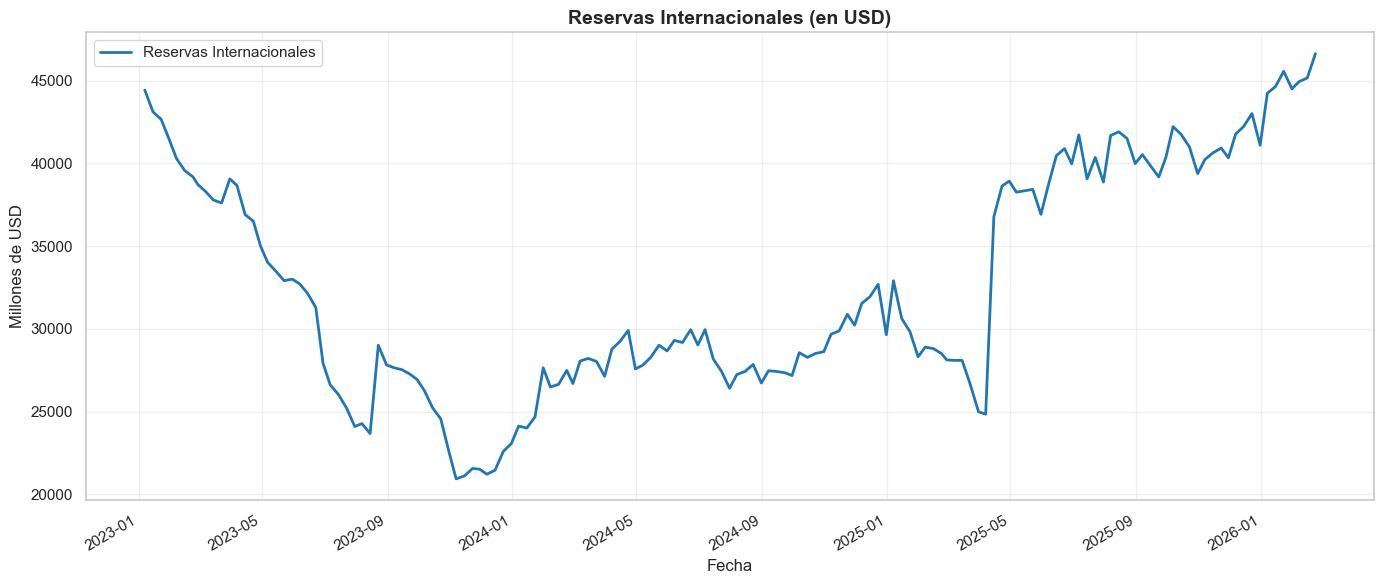

In [6]:
# --- Graficar reservas ---
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(df_usd["fecha"], df_usd["reservas"] / 1e3,
        label="Reservas Internacionales", linewidth=2, color="#1f77b4")

ax.set_title("Reservas Internacionales (en USD)", fontsize=14, fontweight="bold")
ax.set_xlabel("Fecha")
ax.set_ylabel("Millones de USD")
ax.legend()
ax.grid(True, alpha=0.3)
fig.autofmt_xdate()

plt.tight_layout()
plt.show()

In [7]:
# --- Graficar reservas ---
import plotly.graph_objects as go

df_usd_1 = df_usd[df_usd["fecha"] >= "2025-01-01"]

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=df_usd_1["fecha"],
    y=df_usd_1["depositos_gobierno"] / 1e3,
    mode="lines",
    name="Depósitos Gobierno",
    line=dict(color="#1f77b4", width=2)
))

fig.update_layout(
    title="Depósitos del Gobierno Nacional (en USD)",
    xaxis_title="Fecha",
    yaxis_title="Millones de USD",
    hovermode="x unified",
    template="plotly_white",
    width=1000,
    height=500
)

fig.show()

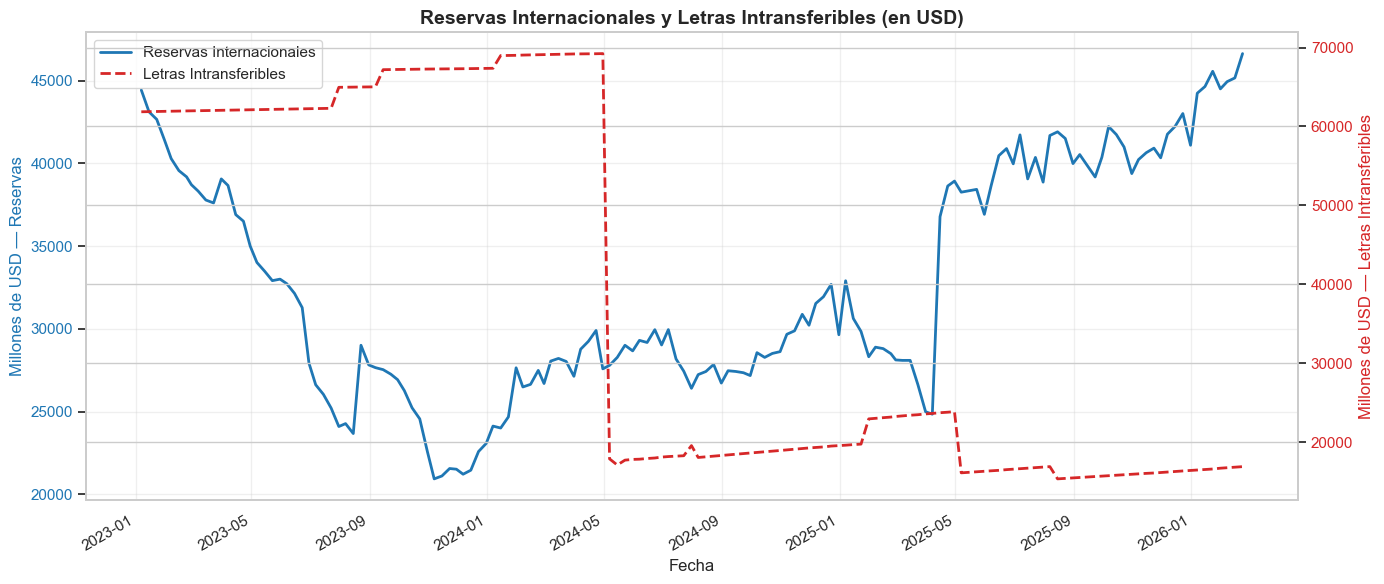

In [8]:
# --- Graficar reservas + letras intransferibles (doble eje) ---
fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.plot(df_usd["fecha"], df_usd["reservas"] / 1e3,
         label="Reservas Internacionales", linewidth=2, color="#1f77b4")
ax1.set_xlabel("Fecha")
ax1.set_ylabel("Millones de USD — Reservas", color="#1f77b4")
ax1.tick_params(axis="y", labelcolor="#1f77b4")
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(df_usd["fecha"], df_usd["letras_intransferibles"] / 1e3,
         label="Letras Intransferibles", linewidth=2, color="#d62728", linestyle="--")
ax2.set_ylabel("Millones de USD — Letras Intransferibles", color="#d62728")
ax2.tick_params(axis="y", labelcolor="#d62728")

# Leyenda combinada
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

ax1.set_title("Reservas Internacionales y Letras Intransferibles (en USD)", fontsize=14, fontweight="bold")
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

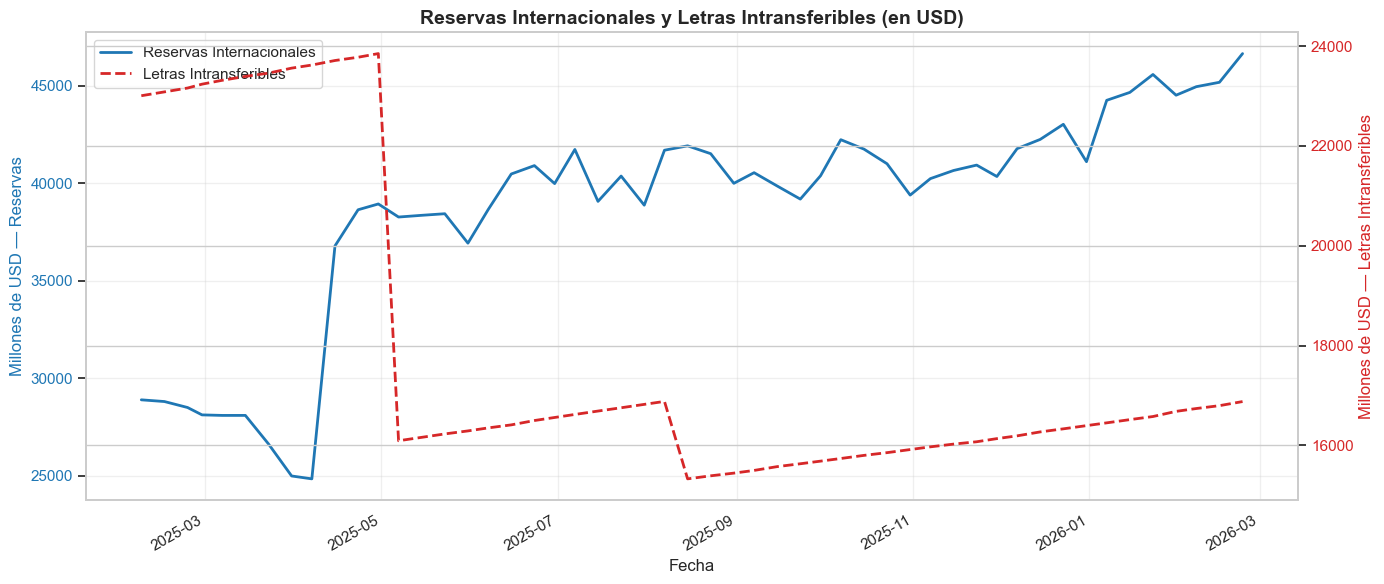

In [9]:
# --- Graficar reservas + letras intransferibles (doble eje) ---
df_usd = df_usd[df_usd["fecha"] >= "2025-02-01"]
fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.plot(df_usd["fecha"], df_usd["reservas"] / 1e3,
         label="Reservas Internacionales", linewidth=2, color="#1f77b4")
ax1.set_xlabel("Fecha")
ax1.set_ylabel("Millones de USD — Reservas", color="#1f77b4")
ax1.tick_params(axis="y", labelcolor="#1f77b4")
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(df_usd["fecha"], df_usd["letras_intransferibles"] / 1e3,
         label="Letras Intransferibles", linewidth=2, color="#d62728", linestyle="--")
ax2.set_ylabel("Millones de USD — Letras Intransferibles", color="#d62728")
ax2.tick_params(axis="y", labelcolor="#d62728")

# Leyenda combinada
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

ax1.set_title("Reservas Internacionales y Letras Intransferibles (en USD)", fontsize=14, fontweight="bold")
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

In [10]:
df_usd.to_excel("df_usd.xlsx", index=False)
print("Guardado en df_usd.xlsx")

PermissionError: [Errno 13] Permission denied: 'df_usd.xlsx'

In [ ]:
import os
print(os.getcwd())


c:\Users\Admin\Documents\GitHub\VJaroszewski-econ\codigos\Codigos_resNet
